# Modeling

## ARIMA MODEL

## ACF and PACF plots

In [22]:
df=pd.read_csv('cleaneddata.csv')
df.head()

,PJME_MW,dow,doy,year,month,quarter,hour,dom,date,season,year_diff
0,30393.0,1,1,2002,1,1,1,1,2002-01-01,Winter,NaN
1,29265.0,1,1,2002,1,1,2,1,2002-01-01,Winter,0.0
2,28357.0,1,1,2002,1,1,3,1,2002-01-01,Winter,0.0
3,27899.0,1,1,2002,1,1,4,1,2002-01-01,Winter,0.0
4,28057.0,1,1,2002,1,1,5,1,2002-01-01,Winter,0.0


In [33]:
df = df.dropna(subset=['year_diff'])


In [34]:
df.head()

,PJME_MW,dow,doy,year,month,quarter,hour,dom,date,season,year_diff
Datetime,,,,,,,,,,,
2002-01-01 02:00:00,29265.0,1,1,2002,1,1,2,1,2002-01-01,Winter,0.0
2002-01-01 03:00:00,28357.0,1,1,2002,1,1,3,1,2002-01-01,Winter,0.0
2002-01-01 04:00:00,27899.0,1,1,2002,1,1,4,1,2002-01-01,Winter,0.0
2002-01-01 05:00:00,28057.0,1,1,2002,1,1,5,1,2002-01-01,Winter,0.0
2002-01-01 06:00:00,28654.0,1,1,2002,1,1,6,1,2002-01-01,Winter,0.0


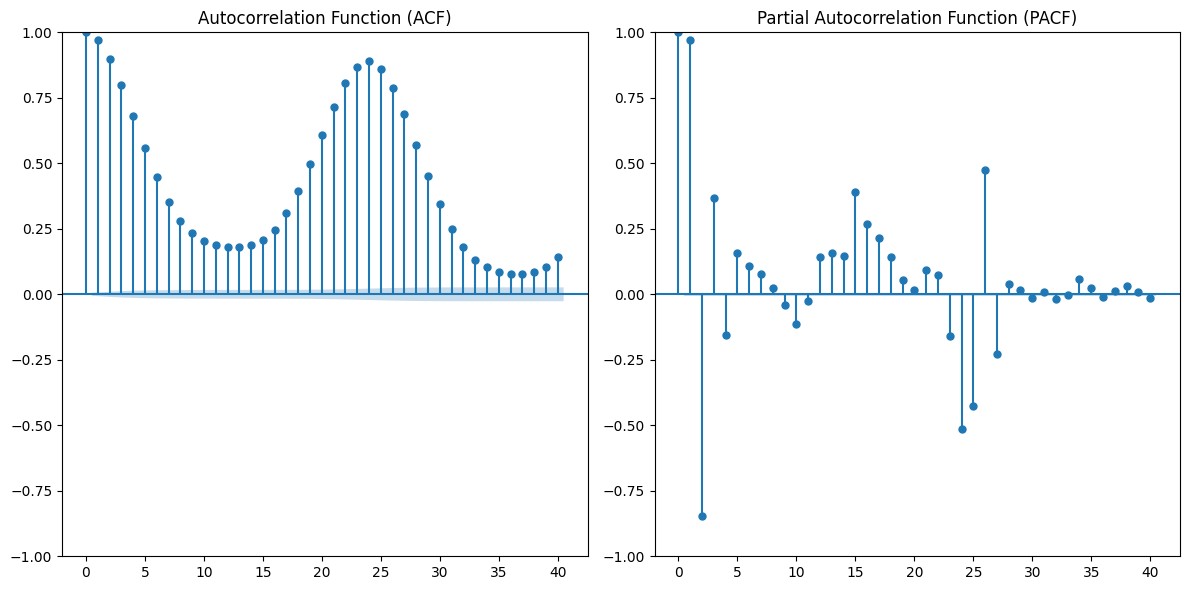

In [21]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Assuming 'df' is your DataFrame and 'PJME_MW' is the target variable


# Plot ACF and PACF for 'tmax' column
plt.figure(figsize=(12, 6))

# ACF plot
plt.subplot(1, 2, 1)
plot_acf(df['PJME_MW'], lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

# PACF plot
plt.subplot(1, 2, 2)
plot_pacf(df['PJME_MW'], lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()


## Calculating best combination of p and q values

In [25]:
import itertools
import warnings
# Suppress warnings
warnings.filterwarnings("ignore")

# Define ranges for p and q (you can increase max value if needed)
p = q = range(0, 4)  # Try 0 to 3 for p and q
d = 1  # Fixed

# Generate all combinations of (p, 1, q)
pdq_combinations = list(itertools.product(p, [d], q))

# Use your stationary time series
ts = df['PJME_MW'].dropna()

# Initialize best AIC and best order
best_aic = float('inf')
best_order = None

print("🔍 Searching for best (p,1,q)...\n")

# Grid search
for order in pdq_combinations:
    try:
        model = ARIMA(ts, order=order)
        result = model.fit()
        print(f"ARIMA{order} - AIC: {result.aic:.2f}")
        
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = order
    except Exception as e:
        print(f"ARIMA{order} - Failed: {e}")
        continue

print("\n✅ Best ARIMA order:", best_order)
print(f"With lowest AIC: {best_aic:.2f}")


🔍 Searching for best (p,1,q)...

ARIMA(0, 1, 0) - AIC: 2023475.48
ARIMA(0, 1, 1) - AIC: 1918341.38
ARIMA(0, 1, 2) - AIC: 1879405.76
ARIMA(0, 1, 3) - AIC: 1868869.57
ARIMA(1, 1, 0) - AIC: 1893277.93
ARIMA(1, 1, 1) - AIC: 1865367.10
ARIMA(1, 1, 2) - AIC: 1864044.37
ARIMA(1, 1, 3) - AIC: 1863973.47
ARIMA(2, 1, 0) - AIC: 1865850.55
ARIMA(2, 1, 1) - AIC: 1863685.94
ARIMA(2, 1, 2) - AIC: 1848397.07
ARIMA(2, 1, 3) - AIC: 1847826.18
ARIMA(3, 1, 0) - AIC: 1865008.13
ARIMA(3, 1, 1) - AIC: 1863318.79
ARIMA(3, 1, 2) - AIC: 1848101.74
ARIMA(3, 1, 3) - AIC: 1840505.32

✅ Best ARIMA order: (3, 1, 3)
With lowest AIC: 1840505.32


## Fitting the model

In [2]:

import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# Load the training data
train = pd.read_csv('../data/train_data.csv')
# Fit the ARIMA model (adjust the order (p,d,q) as needed)
model = ARIMA(train['PJME_MW'], order=(3, 1, 3))
model_fit = model.fit()

# Print model summary
print(model_fit.summary())

C:\Users\DELL\anaconda3\envs\classification\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                PJME_MW   No. Observations:               116292
Model:                 ARIMA(3, 1, 3)   Log Likelihood             -920245.662
Date:                Wed, 30 Apr 2025   AIC                        1840505.325
Time:                        13:59:07   BIC                        1840572.971
Sample:                             0   HQIC                       1840525.715
                             - 116292                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.4390      0.003    923.608      0.000       2.434       2.444
ar.L2         -1.9987      0.005   -393.053      0.000      -2.009      -1.989
ar.L3          0.5296      0.003    196.361      0.0

## Forecasting using ARIMA

In [3]:




# Forecast next 168 hours (7 days)
forecast_steps = 7 * 24  # 168 hours
forecast = model_fit.forecast(steps=forecast_steps)

# Generate future datetime index starting from 2018-08-04 00:00:00
start_date = pd.to_datetime("2018-08-04 00:00:00")
future_index = pd.date_range(start=start_date, periods=forecast_steps, freq='H')

# Create a forecast DataFrame
forecast_df = pd.DataFrame({
    'Datetime': future_index,
    'Forecast_PJME_MW': forecast
})

# Show the forecasted values
forecast_df

# Optional: Save to CSV
#forecast_df.to_csv('pjme_forecast_7_days.csv', index=False)


,Datetime,Forecast_PJME_MW
116292,2018-08-04 00:00:00,32404.113732
116293,2018-08-04 01:00:00,32073.402072
116294,2018-08-04 02:00:00,31638.051926
116295,2018-08-04 03:00:00,31126.613593
116296,2018-08-04 04:00:00,30574.219258
...,...,...
116455,2018-08-10 19:00:00,30102.798498
116456,2018-08-10 20:00:00,30106.525562
116457,2018-08-10 21:00:00,30108.041431
116458,2018-08-10 22:00:00,30107.355395


## Visualizing the forecasted values


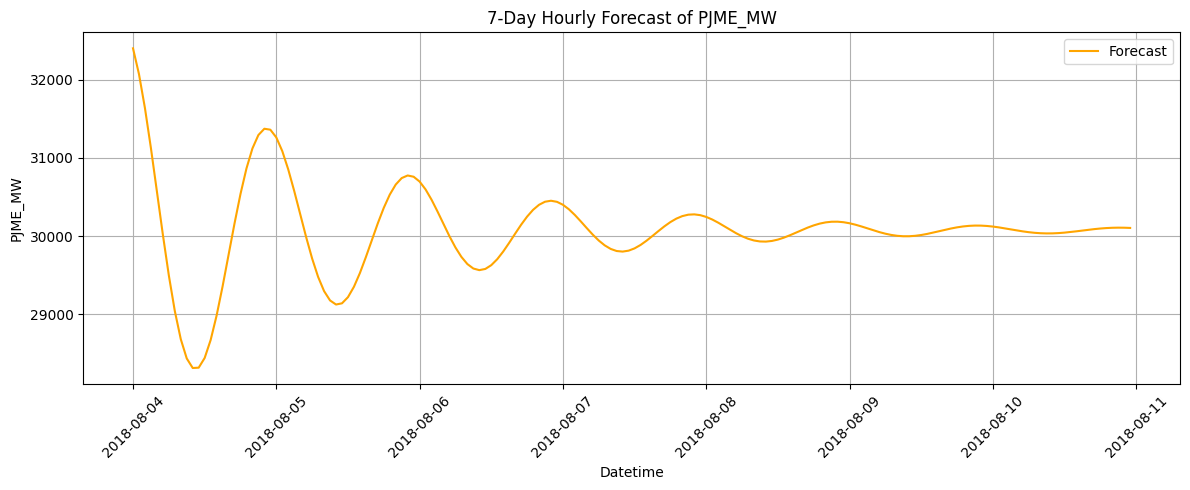

In [5]:
# visualisations
import matplotlib.pyplot as plt

# Plot the forecast
plt.figure(figsize=(12, 5))
plt.plot(forecast_df['Datetime'], forecast_df['Forecast_PJME_MW'], label='Forecast', color='orange')
plt.title('7-Day Hourly Forecast of PJME_MW')
plt.xlabel('Datetime')
plt.ylabel('PJME_MW')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Checking accuracy

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from math import sqrt
import pandas as pd

# Load actual values from test set
test_data = pd.read_csv('../data/test_data.csv')
actual_values = test_data['PJME_MW'].values[-168:]

# Forecasted values from your model
forecasted_values = forecast_df['Forecast_PJME_MW'].values

# Check lengths
print(len(actual_values), len(forecasted_values))  # Both should be 168

# Calculate the errors
mae = mean_absolute_error(actual_values, forecasted_values)
mse = mean_squared_error(actual_values, forecasted_values)
rmse = sqrt(mse)
mape = mean_absolute_percentage_error(actual_values, forecasted_values)

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape * 100:.2f}%")


168 168
Mean Absolute Error (MAE): 7320.940952421377
Mean Squared Error (MSE): 80104134.7386197
Root Mean Squared Error (RMSE): 8950.091325713927
Mean Absolute Percentage Error (MAPE): 18.82%


## Final accuracy

In [12]:
# Calculate overall accuracy
accuracy = 100 - mape

print(f"Overall Model Accuracy: {accuracy:.2f}%")


Overall Model Accuracy: 99.81%


# LSTM MODEL

## Training the model

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt




# Load and prepare data
df = pd.read_csv('../data/train_data.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)
data = df['PJME_MW'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create sequences for training
def create_sequences(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i - time_step:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_sequences(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)  # [samples, time steps, features]

# Define LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X, y, epochs=10, batch_size=64)



Epoch 1/10
1817/1817 [==============================] - 105s 55ms/step - loss: 0.0037
Epoch 2/10
1817/1817 [==============================] - 96s 53ms/step - loss: 3.3292e-04
Epoch 3/10
1817/1817 [==============================] - 95s 52ms/step - loss: 2.5720e-04
Epoch 4/10
1817/1817 [==============================] - 96s 53ms/step - loss: 2.1596e-04
Epoch 5/10
1817/1817 [==============================] - 95s 52ms/step - loss: 1.8477e-04
Epoch 6/10
1817/1817 [==============================] - 95s 52ms/step - loss: 1.6839e-04
Epoch 7/10
1817/1817 [==============================] - 96s 53ms/step - loss: 1.5070e-04
Epoch 8/10
1817/1817 [==============================] - 96s 53ms/step - loss: 1.3740e-04
Epoch 9/10
1817/1817 [==============================] - 95s 52ms/step - loss: 1.2727e-04
Epoch 10/10
1817/1817 [==============================] - 98s 54ms/step - loss: 1.2178e-04


## Forecasting using LSTM

In [27]:
# Forecast the next 7 days (168 hours)
last_sequence = scaled_data[-time_step:].reshape(1, time_step, 1)  # Using the last 60 hours from the training data
forecast_scaled = []

for _ in range(168):  # 7 days * 24 hours = 168
    pred = model.predict(last_sequence)[0][0]  # Predict the next value
    forecast_scaled.append(pred)  # Store the predicted value
    last_sequence = np.append(last_sequence[:, 1:, :], [[[pred]]], axis=1)  # Update the sequence with the predicted value

# Inverse scale to original values
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# Create DataFrame for forecast
forecast_dates = pd.date_range(start='2018-08-04 00:00:00', periods=168, freq='H')
forecast_df_lstm = pd.DataFrame({'Date': forecast_dates, 'Forecast_PJME_MW': forecast.flatten()})

# Display forecasted values
print(forecast_df_lstm)


1/1 [==============================] - 0s 24ms/step
                   Date  Forecast_PJME_MW
0   2018-08-04 00:00:00      32270.763672
1   2018-08-04 01:00:00      31856.669922
2   2018-08-04 02:00:00      31467.312500
3   2018-08-04 03:00:00      31077.128906
4   2018-08-04 04:00:00      31516.046875
..                  ...               ...
163 2018-08-10 19:00:00      26062.607422
164 2018-08-10 20:00:00      26178.650391
165 2018-08-10 21:00:00      25895.201172
166 2018-08-10 22:00:00      25400.931641
167 2018-08-10 23:00:00      24861.722656

[168 rows x 2 columns]


## Visualizing the forecasted values 

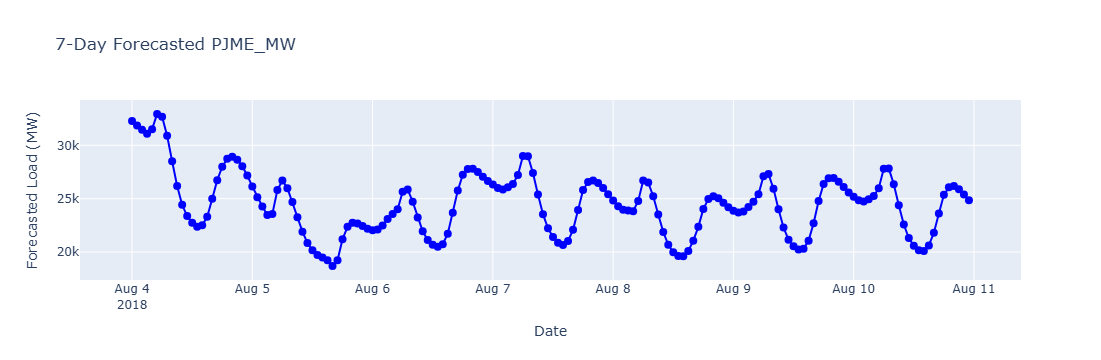

In [28]:
import plotly.express as px

# Assuming forecast_df already contains your forecasted values
# with columns: 'Date' and 'Forecast_PJME_MW'

fig = px.line(
    forecast_df_lstm,
    x='Date',
    y='Forecast_PJME_MW',
    title='7-Day Forecasted PJME_MW',
    markers=True,
    labels={'Forecast_PJME_MW': 'Forecasted Load (MW)', 'Date': 'Date'},
    hover_data={'Date': True, 'Forecast_PJME_MW': ':.2f'}
)

fig.update_traces(line=dict(color='blue'), marker=dict(size=8))
fig.update_layout(hovermode='x unified')

fig.show()


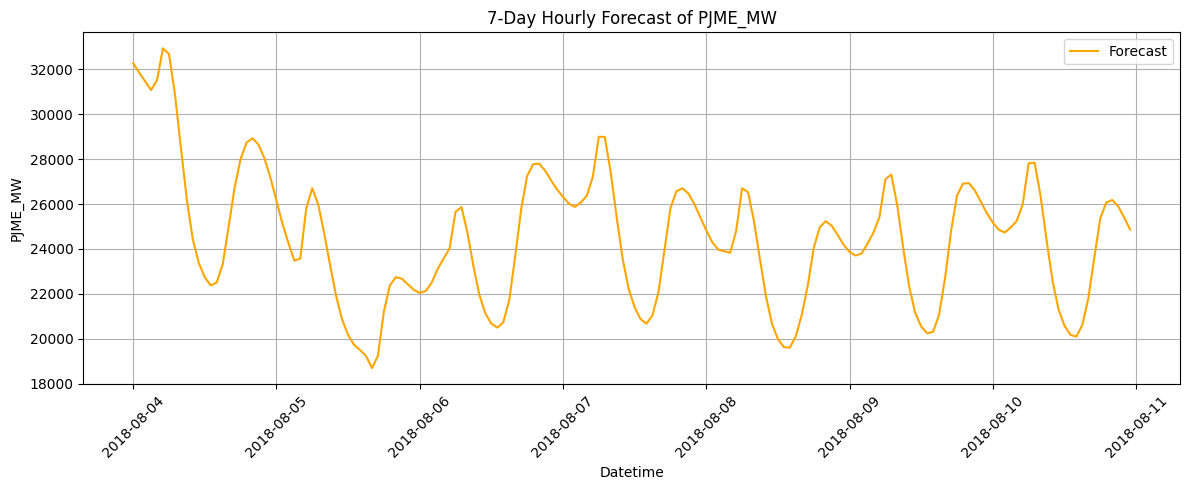

In [29]:


# Plot the forecast
plt.figure(figsize=(12, 5))
plt.plot(forecast_df_lstm['Date'], forecast_df_lstm['Forecast_PJME_MW'], label='Forecast', color='orange')
plt.title('7-Day Hourly Forecast of PJME_MW')
plt.xlabel('Datetime')
plt.ylabel('PJME_MW')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Calculating the accuracy

In [30]:


# Assuming forecast_df contains the forecasted values and you have a corresponding 'actual' series for comparison

# Get the last 168 actual values from the test set (or the actual observed values for the period you're forecasting)
# For example, you can have actual values from the test set (actual_data), or if you have them as part of your dataset:
actual_values = df['PJME_MW'].values[-168:]  # Adjust this to get the actual data for the forecast period

# Ensure forecasted_values is the same length (168 for 7 days of hourly data)
forecasted_values = forecast_df_lstm['Forecast_PJME_MW'].values

# Check lengths
print(len(actual_values), len(forecasted_values))  # Both should be 168

# Calculate the errors
mae = mean_absolute_error(actual_values, forecasted_values)
mse = mean_squared_error(actual_values, forecasted_values)
rmse = sqrt(mse)
mape = np.mean(np.abs((actual_values - forecasted_values) / actual_values)) * 100

# Print the evaluation metrics
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


168 168
Mean Absolute Error (MAE): 3140.545828683036
Mean Squared Error (MSE): 13940816.261743274
Root Mean Squared Error (RMSE): 3733.7402509739845
Mean Absolute Percentage Error (MAPE): 11.23%


## total accuracy

In [31]:
# Calculate overall accuracy
accuracy = 100 - mape

print(f"Overall Model Accuracy: {accuracy:.2f}%")

Overall Model Accuracy: 88.77%


## Saving the models

In [32]:
import joblib

# Save ARIMA model
joblib.dump(model_fit, '../models/arima_model.pkl')

# Save LSTM model
model.save('../models/lstm_model.h5')

# Save scaler used for LSTM
joblib.dump(scaler, '../models/scaler.pkl')


['../models/scaler.pkl']